# S&P 500 Returns and U.S. Macro Indicators — VAR / IRF Analysis (Layer 2)

**Objective:** Explore the dynamic relationship between the S&P 500 returns and the macroeconomic variables without assuming exogeneity, addressing the endogeneity concerns raised in the OLS model (Fed reacts to market  conditions as well as influencing them). Granger test will be applied to identify the dirrection of predictability, impulse-response function (IRF) will show the magnitude and duration of the effects over time.

## 1. Load Dataset and Build Stationary Variable Set

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sp500_macro_monthly_1990_2026.csv', index_col= 0, parse_dates=True)

df.head()

,unemployment_rate,fed_rate,indpro,gs10,usrec,sp500_close,inflation_yoy,sp500_log_return,log_indpro
1991-01-01,6.4,6.91,61.1355,8.09,1.0,343.929993,5.647059,4.067902,4.113093
1991-02-01,6.6,6.25,60.6838,7.85,1.0,367.070007,5.312500,6.511446,4.105677
1991-03-01,6.8,6.12,60.3346,8.11,1.0,375.220001,4.821151,2.195994,4.099906
1991-04-01,6.7,5.91,60.4938,8.04,0.0,375.339996,4.809930,0.031975,4.102541
1991-05-01,6.9,5.78,61.0633,8.07,0.0,389.829987,5.034857,3.787844,4.111911


In [4]:
# Recreate the first-differenced variables (confirmed stationary in notebook 03)
vars_to_diff = ['unemployment_rate', 'fed_rate', 'gs10']

for col in vars_to_diff:
    df[f"{col}_diff"] = df[col].diff()

df = df.dropna(subset = [f"{col}_diff" for col in vars_to_diff])

print(df.head())

            unemployment_rate  fed_rate   indpro  gs10  usrec  sp500_close  \
1991-02-01                6.6      6.25  60.6838  7.85    1.0   367.070007   
1991-03-01                6.8      6.12  60.3346  8.11    1.0   375.220001   
1991-04-01                6.7      5.91  60.4938  8.04    0.0   375.339996   
1991-05-01                6.9      5.78  61.0633  8.07    0.0   389.829987   
1991-06-01                6.9      5.90  61.5581  8.28    0.0   371.160004   

            inflation_yoy  sp500_log_return  log_indpro  \
1991-02-01       5.312500          6.511446    4.105677   
1991-03-01       4.821151          2.195994    4.099906   
1991-04-01       4.809930          0.031975    4.102541   
1991-05-01       5.034857          3.787844    4.111911   
1991-06-01       4.695920         -4.907747    4.119981   

            unemployment_rate_diff  fed_rate_diff  gs10_diff  
1991-02-01                     0.2          -0.66      -0.24  
1991-03-01                     0.2          -0.13 

## 2. Define VAR System and Select Lag Order

In [5]:
from statsmodels.tsa.api import VAR

var_cols = ['sp500_log_return', 'unemployment_rate_diff', 'fed_rate_diff', 'gs10_diff', 'inflation_yoy']
df_var = df[var_cols].dropna()

print(df_var.shape)

(425, 5)


In [6]:
model_var = VAR(df_var)
lag_selection = model_var.select_order(maxlags=12)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -4.086      -4.037     0.01681      -4.066
1       -7.438      -7.146   0.0005882      -7.323
2       -7.731     -7.195*   0.0004391     -7.519*
3      -7.747*      -6.968  0.0004321*      -7.439
4       -7.715      -6.692   0.0004461      -7.311
5       -7.683      -6.417   0.0004608      -7.182
6       -7.632      -6.122   0.0004854      -7.035
7       -7.599      -5.845   0.0005023      -6.905
8       -7.545      -5.548   0.0005304      -6.755
9       -7.490      -5.249   0.0005612      -6.604
10      -7.452      -4.968   0.0005839      -6.470
11      -7.459      -4.731   0.0005813      -6.380
12      -7.412      -4.441   0.0006105      -6.237
--------------------------------------------------


c:\Users\jmich\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 3. Fit VAR Model (lag = 2, selected by BIC)

### VAR Order Selection Results (BIC criterion)
AIC and FPE favored lag=3, while BIC and HQIC favored lag=2. This divergence is expected: AIC/FPE penalize model complexity less strictly than BIC/HQIC, so they tend to favor more lags. BIC is used as the primary criterion here(more conservative, better suited given the sample size of 424 observations and a 5-variable system), and the difference in fit between lag=2 and lag=3 is marginal across all criteria.

In [7]:
var_result = model_var.fit(2)
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 18, Aug, 2026
Time:                     00:07:29
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -7.23300
Nobs:                     423.000    HQIC:                  -7.55132
Log likelihood:          -1304.97    FPE:                0.000426799
AIC:                     -7.75926    Det(Omega_mle):     0.000375385
--------------------------------------------------------------------
Results for equation sp500_log_return
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                             2.028597         0.437942            4.632           0.000
L1.sp500_log_return              -0.031075         0.049245           -0.631           0.528
L

## 4a. Granger Causality Tests

In [8]:
# Does sp500_log_return Granger-cause each of the other variables?
for target in ['unemployment_rate_diff', 'fed_rate_diff', 'gs10_diff', 'inflation_yoy']:
    print(f"\n--- Does the sp500_long_return Granger-cause {target}?---")
    test_result = var_result.test_causality(caused=target, causing='sp500_log_return', kind='f')
    print(test_result.summary())


--- Does the sp500_long_return Granger-cause unemployment_rate_diff?---
Granger causality F-test. H_0: sp500_log_return does not Granger-cause unemployment_rate_diff. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         10.44          3.000   0.000 (2, 2060)
-----------------------------------------------

--- Does the sp500_long_return Granger-cause fed_rate_diff?---
Granger causality F-test. H_0: sp500_log_return does not Granger-cause fed_rate_diff. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         4.786          3.000   0.008 (2, 2060)
-----------------------------------------------

--- Does the sp500_long_return Granger-cause gs10_diff?---
Granger causality F-test. H_0: sp500_log_return does not Granger-cause gs10_diff. Conclusion: reject H_0 at 5% significance level.
Test stat

## 4b. Granger Causality — Reverse Direction 
Do macro variables Granger-cause S&P 500 returns?

In [9]:
for causing_var in ['unemployment_rate_diff', 'fed_rate_diff', 'gs10_diff', 'inflation_yoy']:
    print(f"\n--- Does {causing_var} Granger-cause sp500_log_return?---")
    test_result = var_result.test_causality(caused='sp500_log_return', causing= causing_var, kind='f')
    print(test_result.summary())


--- Does unemployment_rate_diff Granger-cause sp500_log_return?---
Granger causality F-test. H_0: unemployment_rate_diff does not Granger-cause sp500_log_return. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.1120          3.000   0.894 (2, 2060)
-----------------------------------------------

--- Does fed_rate_diff Granger-cause sp500_log_return?---
Granger causality F-test. H_0: fed_rate_diff does not Granger-cause sp500_log_return. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         2.153          3.000   0.116 (2, 2060)
-----------------------------------------------

--- Does gs10_diff Granger-cause sp500_log_return?---
Granger causality F-test. H_0: gs10_diff does not Granger-cause sp500_log_return. Conclusion: fail to reject H_0 at 5% significance level.


### 5. Impulse-Response Functions (IRF)
Although inflation_yoy is the only variable that Granger-causes sp500_log_return, IRFs are also generated for unemployment_rate_diff, fed_rate_diff, and gs10_diff in the REVERSE direction (sp500_log_return -> each variable), since Granger causality tests confirmed that sp500_log_return significantly predicts all four macro variables

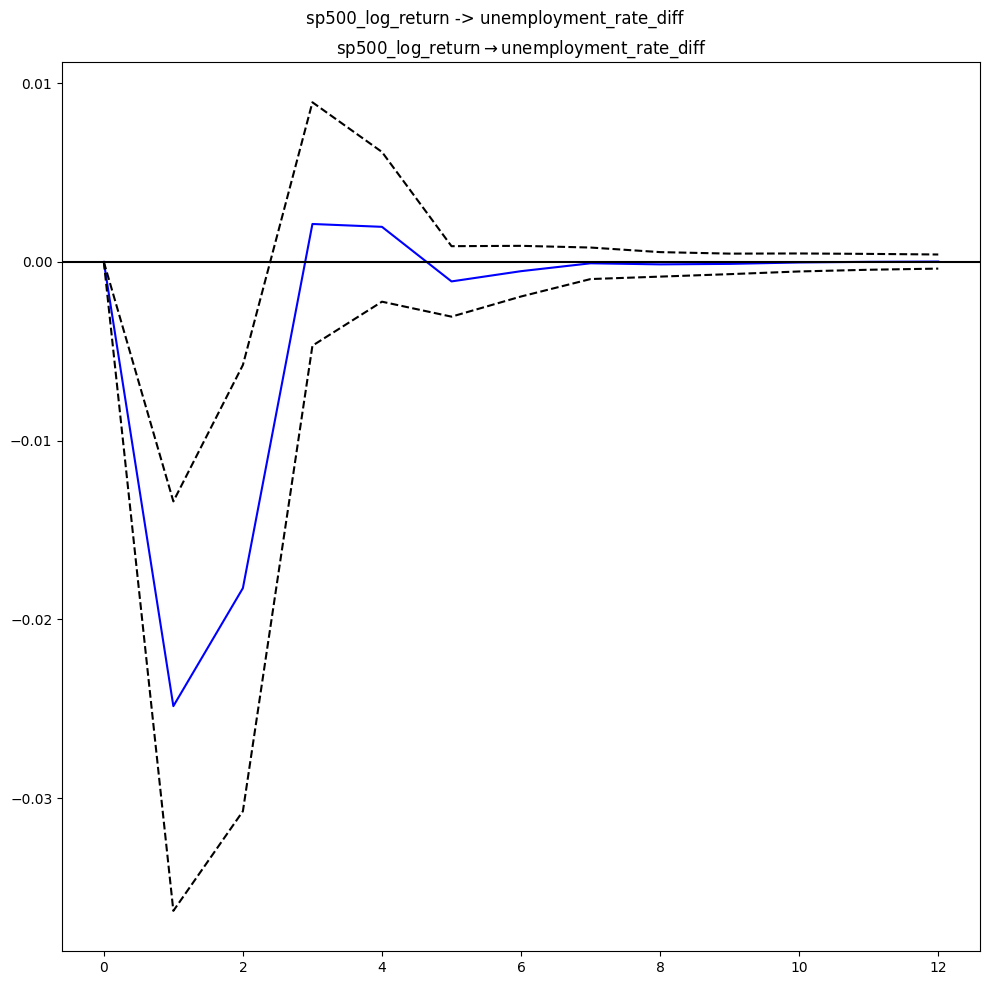

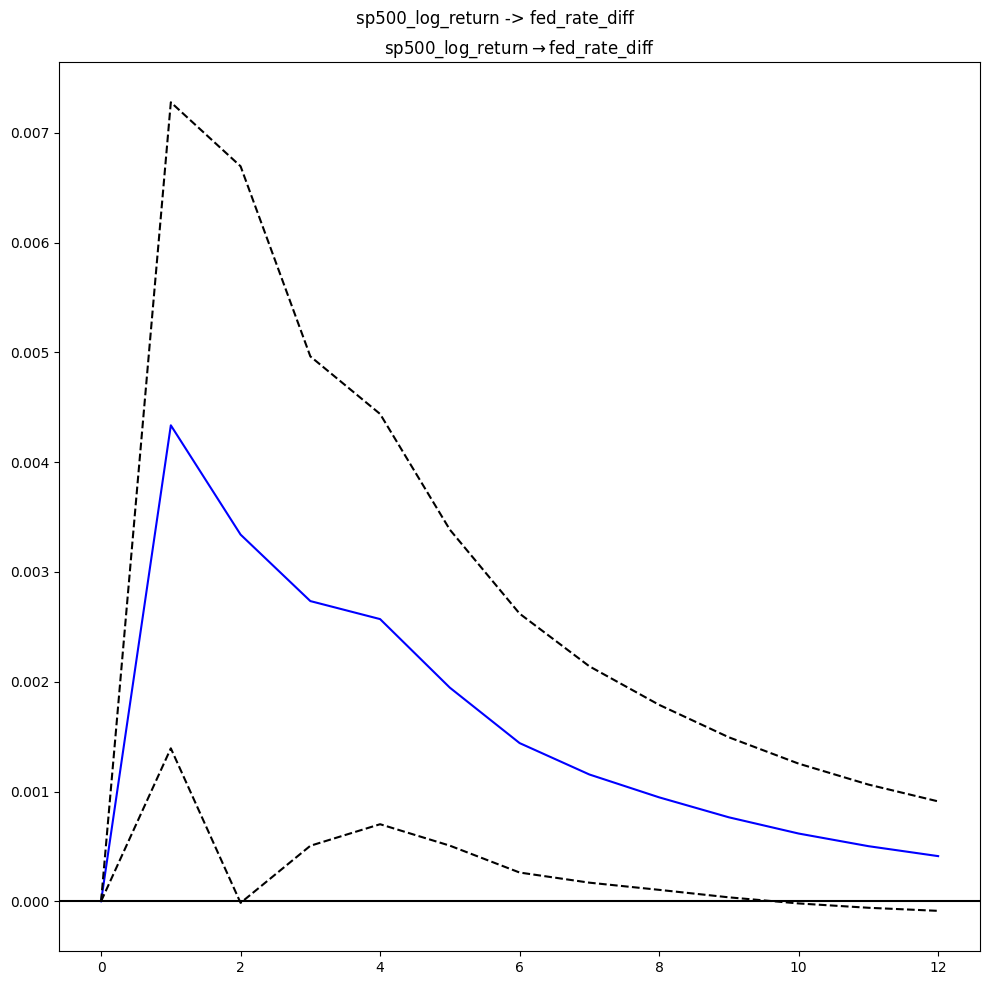

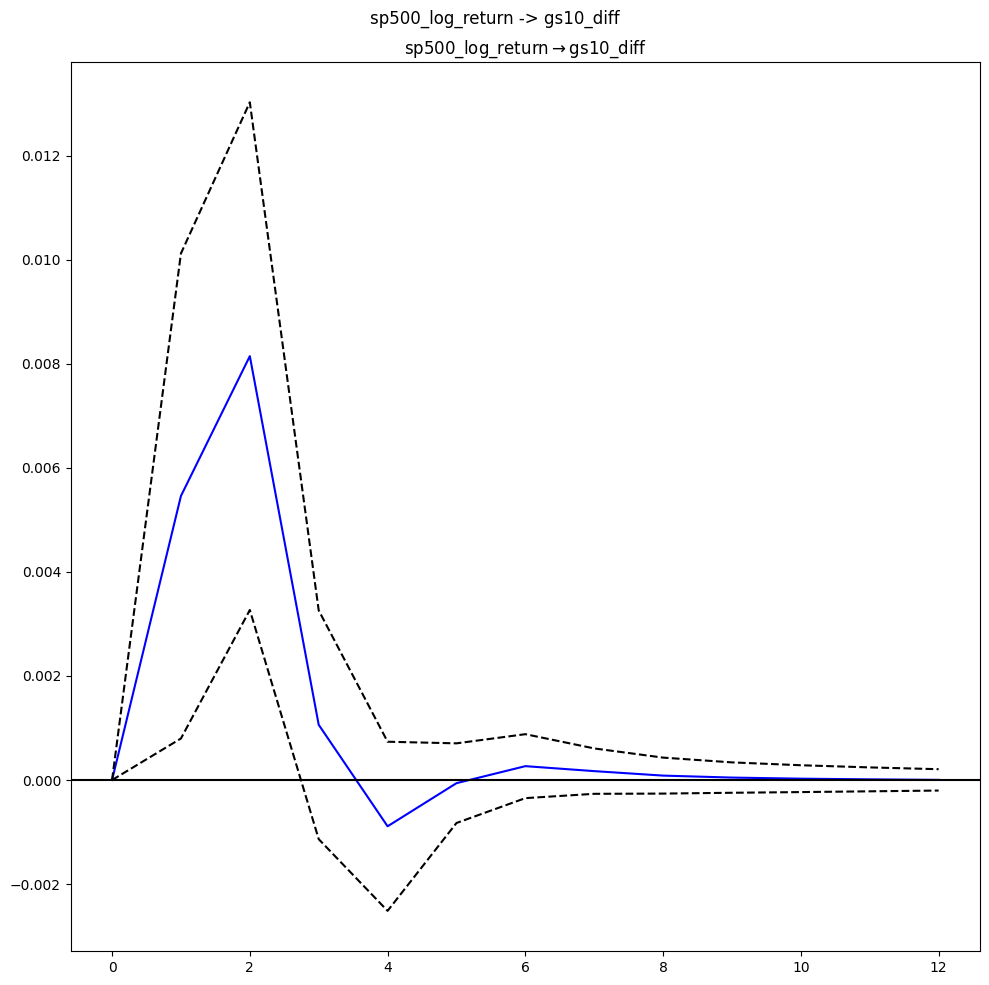

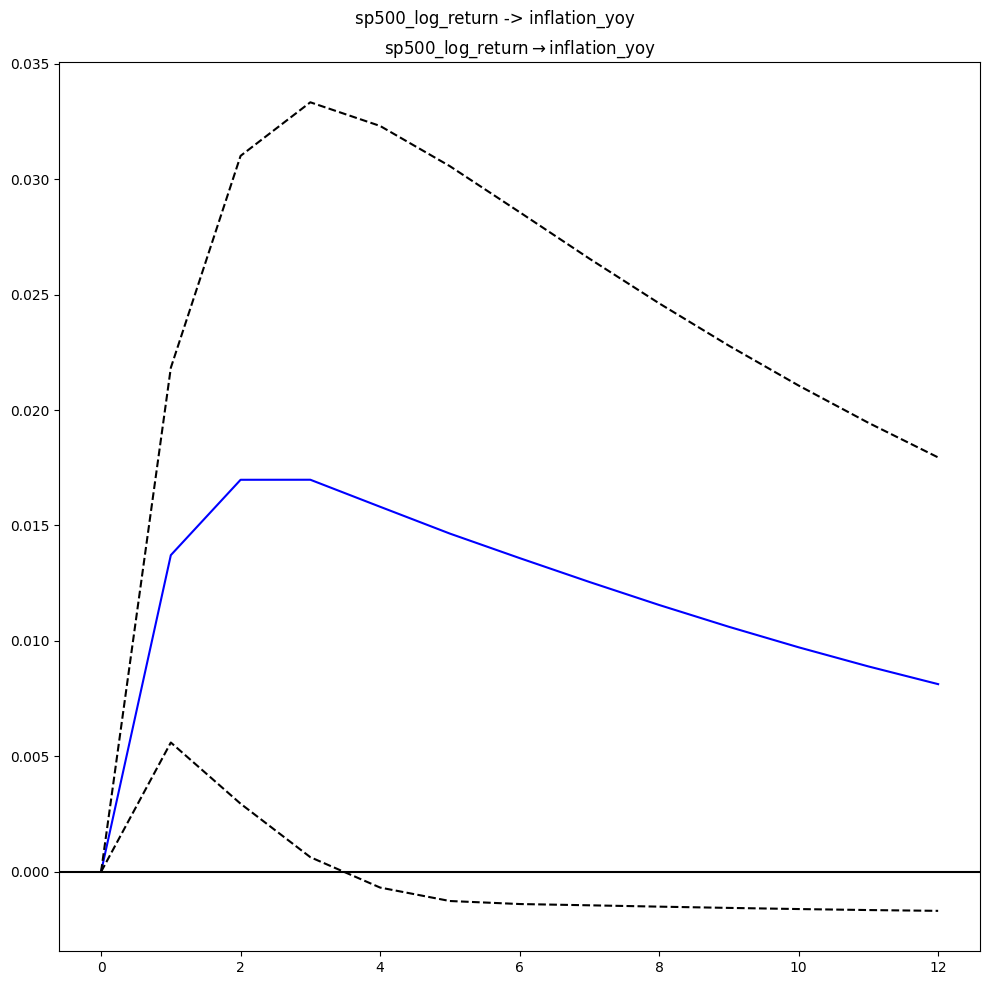

In [10]:
irf = var_result.irf(periods=12)

targets = ['unemployment_rate_diff', 'fed_rate_diff', 'gs10_diff', 'inflation_yoy']

# First: the 4 directions where sp500 is the impulse (confirmed by Granger)
for target in targets:
    irf.plot(orth=False, impulse='sp500_log_return', response=target, signif=0.05)
    plt.suptitle(f'sp500_log_return -> {target}')
    plt.tight_layout()
    plt.show()


        

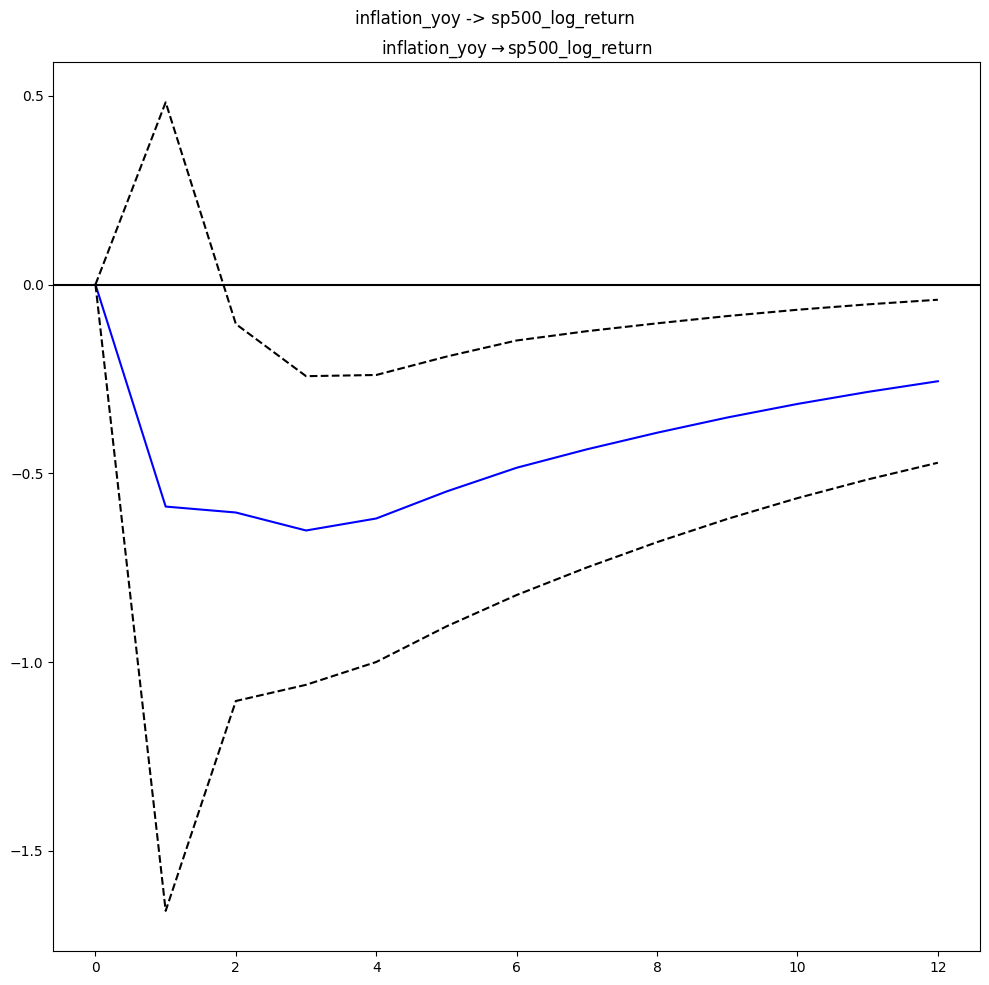

In [11]:
# Second: the reverse relation that proved significant
irf.plot(orth=False, impulse='inflation_yoy', response='sp500_log_return', signif=0.05)
plt.suptitle('inflation_yoy -> sp500_log_return')
plt.tight_layout()
plt.savefig("images/irf_inflation_to_sp500.png", dpi=150, bbox_inches='tight')
plt.show()